In [1]:
# -------------------------------------------------------------------
# Setup project path for module imports
# -------------------------------------------------------------------
#
# This step ensures that the reserbugs package (located in the "src/"
# directory of the repository) can be imported when running this
# notebook from within the "notebooks/" folder.
#
# If the reserbugs source code is not installed as a package, we
# manually add the "src/" directory to the Python path.
#
# This allows imports such as:
#
#   from reserbugs.data import CopernicusDataRetriever
#
# to work correctly.
#
# -------------------------------------------------------------------

import sys
from pathlib import Path

sys.path.append(str(Path().resolve().parent / "src"))

In [2]:
# ---------------------------------------------------------------------
# Import data retrieval tools for climate and vegetation variables
# ---------------------------------------------------------------------
# This section imports the core classes used to retrieve environmental
# data for each BioTIME sampling site, including both climate variables
# (ERA5 / ERA5-Land) and vegetation indices (MODIS NDVI).
#
# The workflow is based on two main retrievers:
#
#   • CopernicusDataRetriever
#       Retrieves monthly abiotic variables from the Copernicus Climate
#       Data Store (CDS), including temperature, precipitation, wind,
#       soil moisture, and Leaf Area Index (LAI).
#
#   • ModisDataRetriever
#       Retrieves satellite-derived vegetation data (NDVI) from MODIS
#       products available via NASA Earthdata, and appends these values
#       to the existing climate dataset for each site.
#
# The ModisRetrieverConfig class is used to configure the MODIS data
# retrieval process, including:
#   • local storage directory for downloaded files
#   • authentication strategy (e.g., netrc or interactive login)
#   • dataset-specific parameters (e.g., NDVI product, scaling)
#
# The Path class (from pathlib) is used to define platform-independent
# filesystem paths for storing downloaded MODIS data.
#
# These components together enable a fully reproducible pipeline for
# assembling a combined environmental dataset at monthly resolution.
# ---------------------------------------------------------------------

from reserbugs.data import CopernicusDataRetriever, ModisDataRetriever, ModisRetrieverConfig

In [3]:
# ---------------------------------------------------------------------
# Define study sites for environmental data retrieval
# ---------------------------------------------------------------------
# This dictionary specifies the geographic locations and temporal ranges
# for which climate (ERA5) and vegetation (MODIS NDVI) data will be
# retrieved.
#
# Each entry represents a sampling site and includes:
#   • latitude   → geographic latitude in decimal degrees
#   • longitude  → geographic longitude in decimal degrees
#   • min_year   → first year of data retrieval (inclusive)
#   • max_year   → last year of data retrieval (inclusive)
#
# The selected sites are chosen to represent contrasting biomes and
# environmental conditions, allowing validation of the data retrieval
# pipeline across a wide range of vegetation types:
#
#   • AmazonForest
#       Tropical rainforest (high biomass, high NDVI, low seasonality)
#
#   • SaharaDesert
#       Hyper-arid desert (very low NDVI, minimal vegetation)
#
#   • IowaCropland
#       Temperate agricultural system (strong seasonal NDVI dynamics,
#       with pronounced growing season peaks)
#
#   • AtlanticOcean (optional, commented out)
#       Open water reference site (NDVI ≈ 0 or negative), useful for
#       validating vegetation index behavior over non-vegetated surfaces
#
# These sites are used as benchmark cases to ensure that the retrieval
# pipeline correctly captures expected ecological and climatic patterns.
# ---------------------------------------------------------------------

values_dict = {
    'AmazonForest': {
        'latitude': -3.5,
        'longitude': -62.0,
        'min_year': 2020,
        'max_year': 2022
    },
    'SaharaDesert': {
        'latitude': 23.4162,
        'longitude': 25.6628,
        'min_year': 2020,
        'max_year': 2022
    },
    # 'AtlanticOcean': {
    #     'latitude': 0.0,
    #     'longitude': -30.0,
    #     'min_year': 2020,
    #     'max_year': 2020
    # },
    'IowaCropland': {
        'latitude': 42.0,
        'longitude': -93.5,
        'min_year': 2020,
        'max_year': 2020
    }
}


In [4]:
# ---------------------------------------------------------------------
# Retrieve monthly climate and soil variables from Copernicus CDS
# ---------------------------------------------------------------------
# This step executes the CopernicusDataRetriever to download and process
# monthly abiotic variables from the ERA5 and ERA5-Land reanalysis
# datasets for each defined site.
#
# For each site in ``values_dict``:
#   • Data are retrieved at the specified latitude and longitude
#   • Monthly values are extracted for the period [min_year, max_year]
#   • Variables include temperature, precipitation, wind, soil moisture,
#     and Leaf Area Index (LAI)
#
# The retrieved data are stored in-place within the dictionary under:
#   values_dict[site]['climate_data']
#
# where ``climate_data`` is a pandas DataFrame with:
#   • one row per month
#   • a ``valid_time`` column (datetime)
#   • columns for each environmental variable
#
# The updated dictionary preserves the original site metadata and adds
# the climate dataset, which will be used as the temporal backbone for
# subsequent NDVI retrieval and integration.
# ---------------------------------------------------------------------

values_dict = CopernicusDataRetriever(values_dict).retrieve_data()

Retrieving data for AmazonForest


2026-03-30 16:22:10,066 INFO Request ID is 6ddf0ad2-2e5c-4ea6-9cd9-4756a03816fd
2026-03-30 16:22:10,145 INFO status has been updated to accepted
2026-03-30 16:22:23,741 INFO status has been updated to running
2026-03-30 16:22:31,398 INFO status has been updated to successful


60fd9e6b98bf0914ae6639585d2ee05c.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

Retrieving data for SaharaDesert


2026-03-30 16:22:32,636 INFO Request ID is 2da0f77b-36e1-49ed-b910-b93ba002fd5e
2026-03-30 16:22:32,727 INFO status has been updated to accepted
2026-03-30 16:22:46,266 INFO status has been updated to successful


9f22ba8225884b826df887c97c4977f7.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

Retrieving data for IowaCropland


2026-03-30 16:22:48,567 INFO Request ID is 44dc9bba-0ffa-4af9-a4cc-0822b4ee0ffb
2026-03-30 16:22:48,654 INFO status has been updated to accepted
2026-03-30 16:23:09,808 INFO status has been updated to successful


7787c6f409d9a26d26d97fb43e6e0478.zip:   0%|          | 0.00/131k [00:00<?, ?B/s]

In [5]:
# ---------------------------------------------------------------------
# Save retrieved climate dataset to disk using pickle
# ---------------------------------------------------------------------
# This step serializes the climate dataset obtained from the
# CopernicusDataRetriever and saves it to a binary file using Python's
# pickle module.
#
# Pickle preserves the full structure of the object, including:
#   • nested dictionaries
#   • pandas DataFrames (e.g., 'climate_data')
#   • metadata associated with each site
#
# The output file ('climate_data.pkl') can be reloaded later without
# needing to re-run the data retrieval process, improving efficiency
# and reproducibility of the workflow.
#
# All intermediate and processed datasets are stored in the 'data/' directory.
# ---------------------------------------------------------------------

import pickle

# Define output path
output_path = Path("../outputs/abiotic_data/NDVI_EXAMPLE_climate_data.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save to disk
with open(output_path, "wb") as f:
    pickle.dump(values_dict, f)

In [4]:
# ---------------------------------------------------------------------
# Load previously saved climate dataset from pickle file
# ---------------------------------------------------------------------
# This step deserializes the climate dataset stored in a pickle file
# and restores it into the current Python session.
#
# The loaded object ('values_dict') retains its original structure:
#   • a dictionary of sites
#   • each site contains metadata (latitude, longitude, years)
#   • each site includes a 'climate_data' pandas DataFrame with
#     monthly environmental variables
#
# This allows the workflow to resume without re-downloading data from
# the Copernicus Climate Data Store, improving efficiency and enabling
# reproducible analyses.
# ---------------------------------------------------------------------

import pickle

# Define input path
input_path = Path("../outputs/abiotic_data/NDVI_EXAMPLE_climate_data.pkl")

with open(input_path, "rb") as f:
    values_dict = pickle.load(f)

In [5]:
# ---------------------------------------------------------------------
# Configure and initialize MODIS NDVI data retrieval
# ---------------------------------------------------------------------
# This step prepares the ModisDataRetriever to download and process
# satellite-derived NDVI data for each site.
#
# The ModisRetrieverConfig object defines key parameters for the
# retrieval process:
#
#   • local_path
#       Directory where downloaded MODIS HDF files will be stored.
#
#   • auth_strategy
#       Authentication method for NASA Earthdata access:
#           - "interactive" → prompts user login during execution
#           - "netrc"       → uses stored credentials in a _netrc file
#
#   • cleanup_downloads
#       If set to True, downloaded MODIS HDF files are automatically
#       removed from the local download directory after processing.
#
# The ModisDataRetriever is then initialized with:
#
#   • values_dict
#       Dictionary containing site metadata and previously retrieved
#       climate data (including the 'climate_data' DataFrame).
#
#   • config
#       Configuration object controlling download location,
#       authentication, and dataset-specific parameters.
#
#   • copy_input=True
#       Ensures that the original input dictionary is not modified
#       in-place. Instead, a copy is created and updated with NDVI
#       values, preserving the original data for reproducibility.
#
# After initialization, calling ``retrieve_data()`` will:
#   • authenticate with Earthdata
#   • download MODIS files for each site and month
#   • extract NDVI values at each site's location
#   • append NDVI to the 'climate_data' DataFrame
#   • remove downloaded MODIS files if cleanup_downloads=True
# ---------------------------------------------------------------------

config = ModisRetrieverConfig(
    local_path=Path("data/modis"),
    auth_strategy="interactive",
    cleanup_downloads=True,
    cleanup_only_hdf=False,
)

modis = ModisDataRetriever(
    values_dict,
    config=config,
    copy_input=True
)


In [6]:
# ---------------------------------------------------------------------
# Retrieve MODIS NDVI and integrate with climate dataset
# ---------------------------------------------------------------------
# This step executes the ModisDataRetriever to download MODIS satellite
# data and extract NDVI values for each site and month.
#
# For each site in ``values_dict``:
#   • MODIS data are queried and downloaded via NASA Earthdata
#   • HDF files are processed to extract NDVI at the site's location
#   • NDVI values are temporally aligned with the existing monthly
#     climate data (based on the 'valid_time' column)
#
# The resulting NDVI values are appended to the existing
# 'climate_data' DataFrame as a new column:
#
#   • NDVI → Normalized Difference Vegetation Index (unitless)
#
# The output (``values_with_ndvi``) is a dictionary with the same
# structure as the input, where each site contains:
#   • metadata (latitude, longitude, years)
#   • a 'climate_data' DataFrame including both climate variables
#     and NDVI
#
# This combined dataset provides a unified monthly environmental
# time series for each site, ready for downstream ecological analysis.
# ---------------------------------------------------------------------

values_with_ndvi = modis.retrieve_data()

Enter your Earthdata Login username:  alfallen
Enter your Earthdata password:  ········


QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

...

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

QUEUEING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

PROCESSING TASKS | :   0%|          | 0/1 [00:00<?, ?it/s]

COLLECTING RESULTS | :   0%|          | 0/1 [00:00<?, ?it/s]

In [9]:
# ---------------------------------------------------------------------
# Save combined climate and NDVI dataset to disk using pickle
# ---------------------------------------------------------------------
# This step serializes the fully processed dataset (including both
# climate variables and NDVI) and saves it to a binary file using
# Python's pickle module.
#
# The saved object ('values_with_ndvi') contains:
#   • a dictionary of sites
#   • site metadata (latitude, longitude, temporal range)
#   • a 'climate_data' pandas DataFrame for each site, including:
#         - monthly climate variables (ERA5 / ERA5-Land)
#         - vegetation structure (LAI)
#         - NDVI (MODIS)
#
# Storing the combined dataset allows:
#   • reuse of results without re-running data retrieval
#   • reproducible analyses
#   • efficient sharing of processed data within Python workflows
#
# All intermediate and processed datasets are stored in the 'data/' directory.
# ---------------------------------------------------------------------

import pickle

# Define output path
output_path = Path("../outputs/abiotic_data/NDVI_EXAMPLE_values_with_ndvi.pkl")
output_path.parent.mkdir(parents=True, exist_ok=True)

# Save climate + NDVI data
with open(output_path, "wb") as f:
    pickle.dump(values_with_ndvi, f)

In [10]:
# ---------------------------------------------------------------------
# Load combined climate and NDVI dataset from pickle file
# ---------------------------------------------------------------------
# This step deserializes the previously saved dataset containing both
# climate variables (ERA5 / ERA5-Land) and NDVI (MODIS), restoring it
# into the current Python session.
#
# The loaded object ('ndvi_data') retains its full structure:
#   • a dictionary of sites
#   • site metadata (latitude, longitude, temporal range)
#   • a 'climate_data' pandas DataFrame for each site, including:
#         - monthly climate variables
#         - vegetation structure variables (LAI)
#         - NDVI values
#
# This allows the workflow to resume from a processed state without
# re-running data retrieval or preprocessing steps, improving efficiency
# and ensuring reproducibility.
# ---------------------------------------------------------------------

import pickle

# Define input path
input_path = Path("../outputs/abiotic_data/NDVI_EXAMPLE_values_with_ndvi.pkl")

with open(input_path, "rb") as f:
    ndvi_data = pickle.load(f)

In [11]:
# ---------------------------------------------------------------------
# Inspect NDVI values for each site (validation step)
# ---------------------------------------------------------------------
# This step iterates over all sites in the combined dataset and prints
# a summary of the retrieved NDVI values.
#
# For each site:
#   • The 'climate_data' DataFrame is accessed
#   • The first 12 monthly observations (1 year) are displayed,
#     including:
#         - valid_time → timestamp of the observation
#         - NDVI       → vegetation index (unitless)
#
#   • The minimum and maximum NDVI values are computed to assess:
#         - overall range of vegetation activity
#         - plausibility of retrieved values
#
# This inspection step is used to validate that:
#   • NDVI values fall within expected physical ranges (-1 to 1)
#   • Different sites exhibit distinct vegetation signatures
#     (e.g., low NDVI in deserts, high NDVI in croplands/forests)
#   • Temporal patterns (seasonality) are consistent with known
#     ecological dynamics
# ---------------------------------------------------------------------

for site in values_with_ndvi:
    df = values_with_ndvi[site]["climate_data"]
    print(f"\n{site}")
    print(df[["valid_time", "NDVI"]].head(12))
    print("min NDVI:", df["NDVI"].min())
    print("max NDVI:", df["NDVI"].max())


AmazonForest
    valid_time    NDVI
0   2020-01-01  0.8287
1   2020-02-01  0.7822
2   2020-03-01  0.8126
3   2020-04-01  0.7863
4   2020-05-01  0.8871
5   2020-06-01  0.8432
6   2020-07-01  0.8557
7   2020-08-01  0.8498
8   2020-09-01  0.8430
9   2020-10-01  0.8335
10  2020-11-01  0.8524
11  2020-12-01  0.8356
min NDVI: 0.6808000206947327
max NDVI: 0.9052000045776367

SaharaDesert
    valid_time    NDVI
0   2020-01-01  0.0940
1   2020-02-01  0.1006
2   2020-03-01  0.1069
3   2020-04-01  0.1046
4   2020-05-01  0.0945
5   2020-06-01  0.0939
6   2020-07-01  0.1001
7   2020-08-01  0.1005
8   2020-09-01  0.0976
9   2020-10-01  0.1006
10  2020-11-01  0.0935
11  2020-12-01  0.1008
min NDVI: 0.08940000087022781
max NDVI: 0.10689999908208847

IowaCropland
    valid_time    NDVI
0   2020-01-01  0.2315
1   2020-02-01  0.2285
2   2020-03-01  0.2394
3   2020-04-01  0.2809
4   2020-05-01  0.3134
5   2020-06-01  0.4538
6   2020-07-01  0.7065
7   2020-08-01  0.7018
8   2020-09-01  0.4845
9   2020-10-

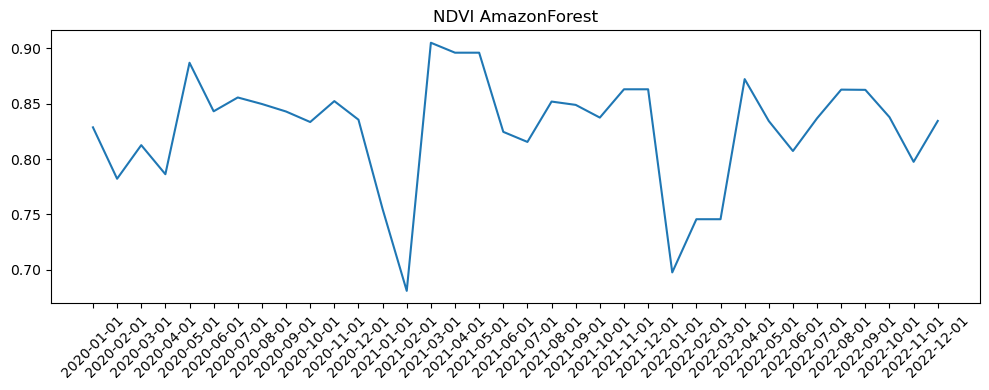

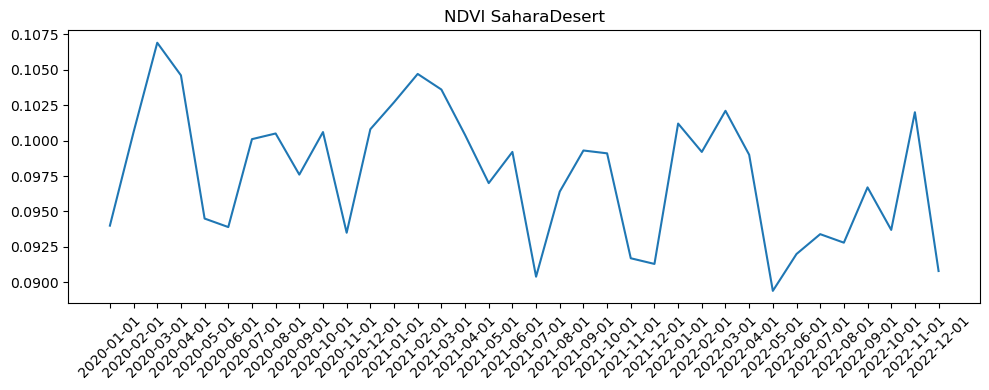

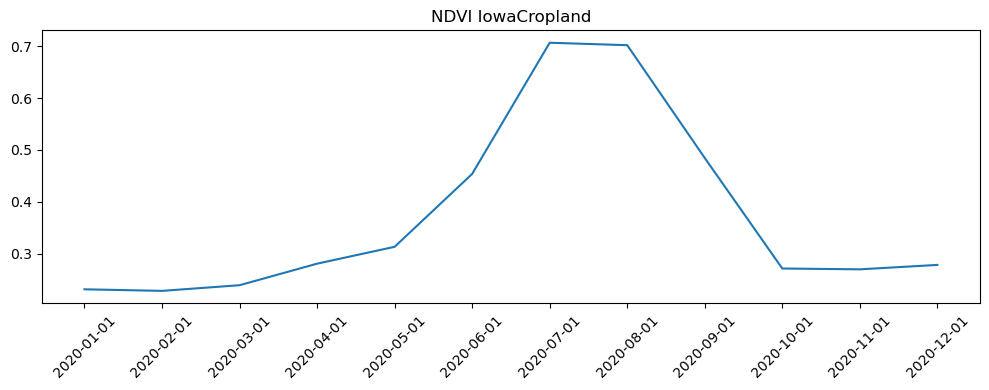

In [12]:
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Visualize and save NDVI time series for each site
# ---------------------------------------------------------------------
# This step generates and saves time series plots of NDVI for each site
# to visually assess vegetation dynamics and seasonal patterns.
#
# For each site in ``values_with_ndvi``:
#   - The 'climate_data' DataFrame is accessed
#   - NDVI values are plotted against time ('valid_time')
#   - The resulting figure is saved to disk
#
# The plots allow visual inspection of:
#   - seasonal vegetation cycles (e.g., cropland growth and harvest)
#   - differences between ecosystems (e.g., forest vs desert)
#   - temporal consistency and smoothness of the NDVI signal
#
# Output:
#   - One figure per site, saved in the "outputs/figures" directory
#   - File format: PNG
#
# ---------------------------------------------------------------------

# Define output directory
output_dir = Path("../outputs/figures/ndvi")
output_dir.mkdir(parents=True, exist_ok=True)

for site in values_with_ndvi:
    df = values_with_ndvi[site]["climate_data"]

    # Create figure
    fig, ax = plt.subplots(figsize=(10, 4))

    # Plot NDVI time series
    ax.plot(df["valid_time"], df["NDVI"])

    # Set title and formatting
    ax.set_title(f"NDVI {site}")
    plt.xticks(rotation=45)
    plt.tight_layout()

    # Define file name
    filename = output_dir / f"ndvi_{site}.png"

    # Save figure
    fig.savefig(filename, dpi=300)

    # Display figure (optional)
    plt.show()

    # Close figure to free memory
    plt.close(fig)